# EUR/USD Walk-Forward ML Backtest — Full System Comparison

This notebook compares multiple signal-construction modes:

1. **Threshold unfiltered**
2. **Threshold + regime filter**
3. **Threshold + regime + confidence filter**
4. **Top-k unfiltered**
5. **Top-k + regime filter**
6. **Top-k + regime + confidence filter**
7. **AUC-gated versions** of all above

Important idea:

> If a walk-forward fold has weak out-of-sample AUC, the model is probably not ranking trades correctly in that regime.  
> So we can block trading in folds where `AUC < AUC_GATE`.

This is a research tool, not production code. In live trading, you would estimate model quality from prior validation windows, not from the same future test fold.


In [1]:
import numpy as np
import pandas as pd
import pandas_ta as ta
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm
from backtesting import Backtest, Strategy
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [2]:
# =========================
# SETTINGS
# =========================

CSV_PATH = "EURUSD_Candlestick_5_M_ASK_30.09.2019-30.09.2022.csv"

N_ROWS = 30000

# Label settings
BARS = 20
D_FRAC = 0.3
SLCOEF = 1.0
TPSL_RATIO = 1.0

# Walk-forward settings
TRAIN_SIZE = 5000
TEST_SIZE = 2500
EMBARGO = BARS

# Signal settings
THRESHOLDS = np.arange(0.50, 0.81, 0.05)
TOP_K_FRACS = [0.03, 0.05, 0.075, 0.10, 0.15]

# Backtest settings
CASH = 250
MARGIN = 1 / 30
COMMISSION = 0.000035

# Regime filter settings
MAX_ATR_RANK = 0.80
MIN_TREND_STRENGTH = 0.50
MAX_VOL_RATIO = 1.80
USE_VOL_RATIO_FILTER = True

# Confidence filter settings
CONF_STD_MULT = 0.30
MIN_PROBA_STD = 0.03

# AUC-gate settings
AUC_GATE = 0.52


In [3]:
# =========================
# LOAD DATA
# =========================

df = pd.read_csv(CSV_PATH)
df = df.loc[:N_ROWS].copy().reset_index(drop=True)

for col in ["Open", "High", "Low", "Close", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Open", "High", "Low", "Close"]).reset_index(drop=True)

df.head()


,Gmt time,Open,High,Low,Close,Volume
0,30.09.2019 00:00:00.000,1.09425,1.09426,1.09405,1.09406,585.10
1,30.09.2019 00:05:00.000,1.09408,1.09414,1.09401,1.09409,289.39
2,30.09.2019 00:10:00.000,1.09410,1.09423,1.09408,1.09410,276.24
3,30.09.2019 00:15:00.000,1.09409,1.09410,1.09388,1.09389,439.29
4,30.09.2019 00:20:00.000,1.09390,1.09395,1.09388,1.09395,341.23


In [4]:
# =========================
# FRACTIONAL DIFFERENCING
# =========================

def get_weights(d, size):
    w = [1.0]
    for k in range(1, size):
        w_ = -w[-1] * (d - k + 1) / k
        w.append(w_)
    return np.array(w[::-1])


def frac_diff(series, d=0.3, thresh=1e-5):
    T = len(series)
    weights = get_weights(d, T)
    weights = weights[np.abs(weights) > thresh]
    width = len(weights)

    output = pd.Series(index=series.index, dtype="float64")

    for i in tqdm(range(width, T), desc="Frac diff"):
        window = series.iloc[i-width:i]
        output.iloc[i] = np.dot(weights, window)

    return output


In [5]:
# =========================
# RAW-PRICE LONG LABELING
# =========================

def atr_label_threshold_long(df, bars=20, d=0.3, slcoef=1.0, TPSLRatio=1.0):
    df = df.copy()

    df["ATR"] = ta.atr(df["High"], df["Low"], df["Close"], length=14)

    tpcoef = slcoef * TPSLRatio
    lower = df["Close"] - slcoef * df["ATR"]
    upper = df["Close"] + tpcoef * df["ATR"]

    df = df.reset_index(drop=True)
    lower = lower.reset_index(drop=True)
    upper = upper.reset_index(drop=True)

    df["Label_Long"] = 0

    for i in tqdm(range(len(df) - bars), desc="Long labels"):
        future_close = df["Close"].iloc[i+1:i+bars+1]

        tp_hit = (future_close >= upper.iloc[i]).any()
        sl_not_hit = (future_close > lower.iloc[i]).all()

        if tp_hit and sl_not_hit:
            df.loc[i, "Label_Long"] = 1

    df["Close_fd"] = frac_diff(df["Close"], d=d)

    return df


df = atr_label_threshold_long(
    df,
    bars=BARS,
    d=D_FRAC,
    slcoef=SLCOEF,
    TPSLRatio=TPSL_RATIO,
)

df[["Close", "ATR", "Close_fd", "Label_Long"]].head()


Long labels:   0%|          | 0/29981 [00:00<?, ?it/s]

Frac diff:   0%|          | 0/27726 [00:00<?, ?it/s]

,Close,ATR,Close_fd,Label_Long
0,1.09406,NaN,NaN,0
1,1.09409,NaN,NaN,0
2,1.09410,NaN,NaN,0
3,1.09389,NaN,NaN,0
4,1.09395,NaN,NaN,0


In [6]:
# =========================
# FEATURE ENGINEERING
# =========================

# Raw EMAs
df["EMA30"] = df["Close"].ewm(span=30, adjust=False).mean()
df["EMA50"] = df["Close"].ewm(span=50, adjust=False).mean()
df["EMA100"] = df["Close"].ewm(span=100, adjust=False).mean()

# Frac-diff EMAs
df["EMA_fd_30"] = df["Close_fd"].ewm(span=30, adjust=False).mean()
df["EMA50_fd"] = df["Close_fd"].ewm(span=50, adjust=False).mean()
df["EMA100_fd"] = df["Close_fd"].ewm(span=100, adjust=False).mean()

# RSI
df["RSI_raw"] = ta.rsi(df["Close"], length=14)
df["RSI_fd"] = ta.rsi(df["Close_fd"], length=14)

# Distance to EMA
df["dist_ema30_raw_norm"] = (df["Close"] - df["EMA30"]) / df["ATR"]
df["dist_ema30_fd_norm"] = (df["Close_fd"] - df["EMA_fd_30"]) / df["ATR"]

# Slopes
df["ema30_slope_raw_norm"] = df["EMA30"].diff(3) / df["ATR"]
df["ema30_slope_fd"] = df["EMA_fd_30"].diff(3)
df["ema30_acc_fd"] = df["ema30_slope_fd"].diff()

# EMA ordering
df["ema_position_raw"] = np.where(
    (df["EMA30"] > df["EMA50"]) & (df["EMA50"] > df["EMA100"]),
    1,
    np.where(
        (df["EMA30"] < df["EMA50"]) & (df["EMA50"] < df["EMA100"]),
        -1,
        0,
    ),
)

df["ema_position_fd"] = np.where(
    (df["EMA_fd_30"] > df["EMA50_fd"]) & (df["EMA50_fd"] > df["EMA100_fd"]),
    1,
    np.where(
        (df["EMA_fd_30"] < df["EMA50_fd"]) & (df["EMA50_fd"] < df["EMA100_fd"]),
        -1,
        0,
    ),
)

df["ema_spread_fd"] = (
    (df["EMA_fd_30"] - df["EMA50_fd"])
    + (df["EMA50_fd"] - df["EMA100_fd"])
)


In [7]:
# =========================
# REGIME FEATURES + REGIME FILTER
# =========================

df["atr_pct"] = df["ATR"] / df["Close"]

df["ret_1"] = df["Close"].pct_change()
df["realized_vol_50"] = df["ret_1"].rolling(50).std()
df["realized_vol_200"] = df["ret_1"].rolling(200).std()

df["vol_ratio_50_200"] = df["realized_vol_50"] / df["realized_vol_200"]

df["trend_strength"] = (df["EMA30"] - df["EMA100"]).abs() / df["ATR"]
df["trend_direction"] = (df["EMA30"] - df["EMA100"]) / df["ATR"]

df["range_50"] = (
    df["High"].rolling(50).max() - df["Low"].rolling(50).min()
) / df["Close"]

df["atr_pct_rank_500"] = df["atr_pct"].rolling(500).rank(pct=True)

df["high_vol_regime"] = (df["atr_pct_rank_500"] > MAX_ATR_RANK).astype(int)
df["weak_trend_regime"] = (df["trend_strength"] < MIN_TREND_STRENGTH).astype(int)
df["vol_expansion_regime"] = (df["vol_ratio_50_200"] > MAX_VOL_RATIO).astype(int)

regime_filter = (
    (df["atr_pct_rank_500"] <= MAX_ATR_RANK)
    & (df["trend_strength"] >= MIN_TREND_STRENGTH)
)

if USE_VOL_RATIO_FILTER:
    regime_filter = regime_filter & (df["vol_ratio_50_200"] <= MAX_VOL_RATIO)

df["regime_trade_allowed"] = regime_filter.astype(int)

print("Regime allowed distribution:")
print(df["regime_trade_allowed"].value_counts(dropna=False))


Regime allowed distribution:
regime_trade_allowed
1    17882
0    12119
Name: count, dtype: int64


In [8]:
# =========================
# MODEL DATA
# =========================

feature_cols = [
    "ATR",
    "RSI_raw",
    "RSI_fd",
    "Close_fd",
    "EMA_fd_30",
    "EMA50_fd",
    "EMA100_fd",
    "dist_ema30_raw_norm",
    "dist_ema30_fd_norm",
    "ema30_slope_raw_norm",
    "ema30_slope_fd",
    "ema30_acc_fd",
    "ema_position_raw",
    "ema_position_fd",
    "ema_spread_fd",

    # regime features for the model
    "atr_pct",
    "realized_vol_50",
    "realized_vol_200",
    "vol_ratio_50_200",
    "trend_strength",
    "trend_direction",
    "range_50",
    "atr_pct_rank_500",
    "high_vol_regime",
    "weak_trend_regime",
    "vol_expansion_regime",
]

target_col = "Label_Long"

df_model = df[
    feature_cols
    + [
        target_col,
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "regime_trade_allowed",
    ]
].copy()

df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna().reset_index(drop=True)

print("df_model shape:", df_model.shape)

print("\nLabel distribution:")
print(df_model[target_col].value_counts())

print("\nBase rate:")
print(df_model[target_col].mean())

print("\nRegime filter distribution:")
print(df_model["regime_trade_allowed"].value_counts())

df_model.head()


df_model shape: (27722, 33)

Label distribution:
Label_Long
0    18465
1     9257
Name: count, dtype: int64

Base rate:
0.3339225164129572

Regime filter distribution:
regime_trade_allowed
1    16826
0    10896
Name: count, dtype: int64


,ATR,RSI_raw,RSI_fd,Close_fd,EMA_fd_30,EMA50_fd,EMA100_fd,dist_ema30_raw_norm,dist_ema30_fd_norm,ema30_slope_raw_norm,...,high_vol_regime,weak_trend_regime,vol_expansion_regime,Label_Long,Open,High,Low,Close,Volume,regime_trade_allowed
0,0.000186,51.326358,15.904325,0.083259,0.083303,0.083312,0.083319,0.197545,-0.236302,-0.008798,...,0,0,0,1,1.09741,1.09741,1.09730,1.09741,212.350,1
1,0.000184,51.961356,16.276916,0.083264,0.083301,0.083310,0.083318,0.288478,-0.201969,0.040854,...,0,0,0,1,1.09738,1.09751,1.09735,1.09743,125.955,1
2,0.000184,53.904236,17.317875,0.083275,0.083299,0.083309,0.083317,0.573994,-0.132457,0.073158,...,0,0,0,1,1.09742,1.09759,1.09740,1.09749,212.060,1
3,0.000175,53.515755,22.119346,0.083325,0.083301,0.083309,0.083317,0.512851,0.141385,0.098064,...,0,0,0,1,1.09749,1.09749,1.09744,1.09748,49.560,1
4,0.000172,54.915407,21.283790,0.083294,0.083300,0.083309,0.083316,0.704068,-0.039096,0.126791,...,0,0,0,1,1.09747,1.09756,1.09742,1.09752,194.060,1


In [9]:
# =========================
# BACKTEST STRATEGY
# =========================

class MLLongStrategy(Strategy):
    def init(self):
        self.signal = self.I(lambda x: x, self.data.Signal)

    def next(self):
        if not self.position and self.signal[-1] == 1:
            price = self.data.Close[-1]

            sl = price - 0.001
            tp = price + 0.001

            self.buy(sl=sl, tp=tp)


def run_backtest_on_slice(test_df, signal):
    df_bt = test_df.copy().reset_index(drop=True)
    df_bt["Signal"] = np.asarray(signal).astype(int)

    df_bt = df_bt[["Open", "High", "Low", "Close", "Volume", "Signal"]].copy()

    bt = Backtest(
        df_bt,
        MLLongStrategy,
        cash=CASH,
        margin=MARGIN,
        commission=COMMISSION,
        exclusive_orders=True,
        finalize_trades=True,
    )

    return bt.run()


In [10]:
# =========================
# SIGNAL HELPERS
# =========================

def make_topk_signal(proba, k_frac):
    n = len(proba)
    k = max(1, int(np.floor(k_frac * n)))
    idx = np.argsort(proba)[-k:]

    signal = np.zeros(n, dtype=int)
    signal[idx] = 1
    return signal


def make_topk_from_allowed(proba, allowed_mask, k_frac):
    n = len(proba)
    allowed_idx = np.where(allowed_mask)[0]

    signal = np.zeros(n, dtype=int)

    if len(allowed_idx) == 0:
        return signal

    k = max(1, int(np.floor(k_frac * len(allowed_idx))))

    allowed_proba = proba[allowed_idx]
    selected_local = np.argsort(allowed_proba)[-k:]
    selected_idx = allowed_idx[selected_local]

    signal[selected_idx] = 1
    return signal


def add_auc_gate(signal, auc, auc_gate=AUC_GATE):
    if np.isnan(auc) or auc < auc_gate:
        return np.zeros_like(signal)
    return signal


In [11]:
# =========================
# WALK-FORWARD TEST:
# THRESHOLDS + TOP-K + REGIME + CONFIDENCE + AUC GATING
# =========================

def walk_forward_full_system_test(
    df_model,
    feature_cols,
    target_col,
    train_size=5000,
    test_size=2500,
    embargo=20,
    thresholds=np.arange(0.50, 0.81, 0.05),
    top_k_fracs=[0.03, 0.05, 0.075, 0.10, 0.15],
):
    results = []
    diagnostics = []
    all_oos = []

    n = len(df_model)
    fold = 0

    for start in range(0, n - train_size - embargo - test_size + 1, test_size):
        fold += 1

        train_start = start
        train_end = start + train_size

        test_start = train_end + embargo
        test_end = test_start + test_size

        train_df = df_model.iloc[train_start:train_end].copy()
        test_df = df_model.iloc[test_start:test_end].copy()

        X_train = train_df[feature_cols]
        y_train = train_df[target_col].astype(int)

        X_test = test_df[feature_cols]
        y_test = test_df[target_col].astype(int)

        if y_train.nunique() < 2 or y_test.nunique() < 2:
            print(f"Fold {fold}: skipped because train/test has one class only.")
            continue

        clf = xgb.XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=30,
            n_jobs=-1,
        )

        clf.fit(X_train, y_train)

        proba = clf.predict_proba(X_test)[:, 1]

        proba_mean = float(np.mean(proba))
        proba_std = float(np.std(proba))
        confidence_cut = proba_mean + CONF_STD_MULT * proba_std
        confidence_allowed = proba_std >= MIN_PROBA_STD

        try:
            auc = roc_auc_score(y_test, proba)
        except Exception:
            auc = np.nan

        auc_gate_passed = (not np.isnan(auc)) and (auc >= AUC_GATE)

        regime_allowed = test_df["regime_trade_allowed"].values.astype(bool)

        if confidence_allowed:
            confidence_mask = proba >= confidence_cut
        else:
            confidence_mask = np.zeros_like(proba, dtype=bool)

        regime_conf_allowed = regime_allowed & confidence_mask

        diagnostics.append({
            "fold": fold,
            "proba_mean": proba_mean,
            "proba_std": proba_std,
            "confidence_cut": confidence_cut,
            "confidence_allowed": confidence_allowed,
            "auc": auc,
            "auc_gate_passed": auc_gate_passed,
            "regime_allowed_count": int(regime_allowed.sum()),
            "regime_conf_allowed_count": int(regime_conf_allowed.sum()),
            "test_size": len(test_df),
            "test_base_rate": float(y_test.mean()),
        })

        fold_oos = test_df.copy()
        fold_oos["fold"] = fold
        fold_oos["proba"] = proba
        fold_oos["y_true"] = y_test.values
        fold_oos["auc"] = auc
        fold_oos["auc_gate_passed"] = auc_gate_passed
        all_oos.append(fold_oos)

        # Threshold modes
        for threshold in thresholds:
            raw_signal = (proba >= threshold).astype(int)

            regime_signal = (
                (proba >= threshold)
                & regime_allowed
            ).astype(int)

            regime_conf_signal = (
                (proba >= threshold)
                & regime_allowed
                & confidence_mask
            ).astype(int)

            signal_map = {
                "threshold_unfiltered": raw_signal,
                "threshold_regime_filtered": regime_signal,
                "threshold_regime_confidence_filtered": regime_conf_signal,
                "threshold_unfiltered_auc_gated": add_auc_gate(raw_signal, auc),
                "threshold_regime_filtered_auc_gated": add_auc_gate(regime_signal, auc),
                "threshold_regime_confidence_filtered_auc_gated": add_auc_gate(regime_conf_signal, auc),
            }

            for mode_name, signal in signal_map.items():
                precision = precision_score(y_test, signal, zero_division=0)
                recall = recall_score(y_test, signal, zero_division=0)

                stats = run_backtest_on_slice(
                    test_df[["Open", "High", "Low", "Close", "Volume"]],
                    signal,
                )

                results.append({
                    "mode": mode_name,
                    "fold": fold,
                    "selector": threshold,
                    "selector_type": "threshold",
                    "auc": auc,
                    "auc_gate_passed": auc_gate_passed,
                    "proba_mean": proba_mean,
                    "proba_std": proba_std,
                    "confidence_cut": confidence_cut,
                    "confidence_allowed": confidence_allowed,
                    "precision": precision,
                    "recall": recall,
                    "signal_count": int(signal.sum()),
                    "regime_allowed_count": int(regime_allowed.sum()),
                    "regime_conf_allowed_count": int(regime_conf_allowed.sum()),
                    "trades": stats["# Trades"],
                    "return_pct": stats["Return [%]"],
                    "win_rate": stats["Win Rate [%]"],
                    "max_drawdown": stats["Max. Drawdown [%]"],
                    "sharpe": stats["Sharpe Ratio"],
                    "equity_final": stats["Equity Final [$]"],
                })

        # Top-k modes
        for k_frac in top_k_fracs:
            topk_unfiltered = make_topk_signal(proba, k_frac)

            topk_regime = make_topk_from_allowed(
                proba=proba,
                allowed_mask=regime_allowed,
                k_frac=k_frac,
            )

            topk_regime_conf = make_topk_from_allowed(
                proba=proba,
                allowed_mask=regime_conf_allowed,
                k_frac=k_frac,
            )

            signal_map = {
                "topk_unfiltered": topk_unfiltered,
                "topk_regime_filtered": topk_regime,
                "topk_regime_confidence_filtered": topk_regime_conf,
                "topk_unfiltered_auc_gated": add_auc_gate(topk_unfiltered, auc),
                "topk_regime_filtered_auc_gated": add_auc_gate(topk_regime, auc),
                "topk_regime_confidence_filtered_auc_gated": add_auc_gate(topk_regime_conf, auc),
            }

            for mode_name, signal in signal_map.items():
                precision = precision_score(y_test, signal, zero_division=0)
                recall = recall_score(y_test, signal, zero_division=0)

                stats = run_backtest_on_slice(
                    test_df[["Open", "High", "Low", "Close", "Volume"]],
                    signal,
                )

                results.append({
                    "mode": mode_name,
                    "fold": fold,
                    "selector": k_frac,
                    "selector_type": "top_k_fraction",
                    "auc": auc,
                    "auc_gate_passed": auc_gate_passed,
                    "proba_mean": proba_mean,
                    "proba_std": proba_std,
                    "confidence_cut": confidence_cut,
                    "confidence_allowed": confidence_allowed,
                    "precision": precision,
                    "recall": recall,
                    "signal_count": int(signal.sum()),
                    "regime_allowed_count": int(regime_allowed.sum()),
                    "regime_conf_allowed_count": int(regime_conf_allowed.sum()),
                    "trades": stats["# Trades"],
                    "return_pct": stats["Return [%]"],
                    "win_rate": stats["Win Rate [%]"],
                    "max_drawdown": stats["Max. Drawdown [%]"],
                    "sharpe": stats["Sharpe Ratio"],
                    "equity_final": stats["Equity Final [$]"],
                })

    oos_df = pd.concat(all_oos, ignore_index=True) if len(all_oos) else pd.DataFrame()

    return pd.DataFrame(results), pd.DataFrame(diagnostics), oos_df


wf_results, fold_diagnostics, oos_predictions = walk_forward_full_system_test(
    df_model=df_model,
    feature_cols=feature_cols,
    target_col=target_col,
    train_size=TRAIN_SIZE,
    test_size=TEST_SIZE,
    embargo=EMBARGO,
    thresholds=THRESHOLDS,
    top_k_fracs=TOP_K_FRACS,
)

display(fold_diagnostics)
wf_results.head()


/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/2500836320.py:25: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(


Backtest.run:   0%|          | 0/2499 [00:00<?, ?bar/s]

,fold,proba_mean,proba_std,confidence_cut,confidence_allowed,auc,auc_gate_passed,regime_allowed_count,regime_conf_allowed_count,test_size,test_base_rate
0,1,0.528859,0.137001,0.569960,True,0.575202,True,1604,741,2500,0.3232
1,2,0.330515,0.129615,0.369399,True,0.527152,True,1572,501,2500,0.3384
2,3,0.269789,0.154133,0.316029,True,0.564274,True,1636,650,2500,0.3448
3,4,0.277103,0.142952,0.319989,True,0.541543,True,1567,613,2500,0.3504
4,5,0.301261,0.127572,0.339532,True,0.475090,False,1437,649,2500,0.3888
5,6,0.367962,0.122476,0.404704,True,0.504133,False,1432,463,2500,0.3548
6,7,0.536344,0.226916,0.604418,True,0.478854,False,1549,490,2500,0.3064
7,8,0.497650,0.251448,0.573084,True,0.485284,False,1463,562,2500,0.3104
8,9,0.360052,0.136753,0.401078,True,0.528915,True,1438,556,2500,0.2640


,mode,fold,selector,selector_type,auc,auc_gate_passed,proba_mean,proba_std,confidence_cut,confidence_allowed,...,recall,signal_count,regime_allowed_count,regime_conf_allowed_count,trades,return_pct,win_rate,max_drawdown,sharpe,equity_final
0,threshold_unfiltered,1,0.5,threshold,0.575202,True,0.528859,0.137001,0.56996,True,...,0.709158,1573,1604,741,46.0,-31.832284,39.130435,-39.099466,NaN,170.419289
1,threshold_regime_filtered,1,0.5,threshold,0.575202,True,0.528859,0.137001,0.56996,True,...,0.504950,988,1604,741,20.0,-14.621542,40.000000,-19.867039,NaN,213.446145
2,threshold_regime_confidence_filtered,1,0.5,threshold,0.575202,True,0.528859,0.137001,0.56996,True,...,0.382426,741,1604,741,19.0,-12.007551,42.105263,-16.715191,NaN,219.981122
3,threshold_unfiltered_auc_gated,1,0.5,threshold,0.575202,True,0.528859,0.137001,0.56996,True,...,0.709158,1573,1604,741,46.0,-31.832284,39.130435,-39.099466,NaN,170.419289
4,threshold_regime_filtered_auc_gated,1,0.5,threshold,0.575202,True,0.528859,0.137001,0.56996,True,...,0.504950,988,1604,741,20.0,-14.621542,40.000000,-19.867039,NaN,213.446145


In [12]:
# =========================
# SUMMARY METRICS
# =========================

summary = (
    wf_results
    .groupby(["mode", "selector_type", "selector"])
    .agg(
        mean_return=("return_pct", "mean"),
        median_return=("return_pct", "median"),
        min_return=("return_pct", "min"),
        std_return=("return_pct", "std"),
        positive_folds=("return_pct", lambda x: (x > 0).mean()),
        mean_trades=("trades", "mean"),
        total_trades=("trades", "sum"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_auc=("auc", "mean"),
        auc_pass_rate=("auc_gate_passed", "mean"),
        mean_drawdown=("max_drawdown", "mean"),
        worst_drawdown=("max_drawdown", "min"),
        mean_sharpe=("sharpe", "mean"),
    )
    .reset_index()
)

# Robust score penalizes tail risk and instability.
summary["robust_score"] = (
    summary["mean_return"]
    + 0.50 * summary["median_return"]
    + 0.25 * summary["min_return"]
    - 0.25 * summary["std_return"].fillna(0)
    + 2.0 * summary["positive_folds"]
)

display(summary.sort_values("robust_score", ascending=False).head(30))


,mode,selector_type,selector,mean_return,median_return,min_return,std_return,positive_folds,mean_trades,total_trades,mean_precision,mean_recall,mean_auc,auc_pass_rate,mean_drawdown,worst_drawdown,mean_sharpe,robust_score
50,topk_regime_confidence_filtered_auc_gated,top_k_fraction,0.100,1.117622,0.000000,-5.273725,3.540843,0.444444,4.111111,37.0,0.266444,0.020614,0.52005,0.555556,-3.533475,-11.565809,NaN,-0.197131
51,topk_regime_confidence_filtered_auc_gated,top_k_fraction,0.150,0.958454,0.000000,-7.907219,4.108552,0.444444,4.777778,43.0,0.243731,0.028108,0.52005,0.555556,-3.542566,-11.565976,NaN,-1.156600
58,topk_regime_filtered_auc_gated,top_k_fraction,0.050,0.763504,0.000000,-7.907219,3.860157,0.444444,4.444444,40.0,0.251933,0.024328,0.52005,0.555556,-3.782684,-11.565976,NaN,-1.289451
67,topk_unfiltered_auc_gated,top_k_fraction,0.030,0.742195,0.000000,-5.694606,4.929510,0.222222,5.666667,51.0,0.223704,0.020869,0.52005,0.555556,-5.084654,-15.367546,NaN,-1.469389
53,topk_regime_filtered,top_k_fraction,0.050,-0.175156,3.010548,-11.116111,6.426685,0.666667,8.222222,74.0,0.406455,0.037609,0.52005,0.555556,-7.776390,-13.526986,NaN,-1.722247
42,topk_regime_confidence_filtered,top_k_fraction,0.030,-0.487772,2.009561,-11.804222,7.013384,0.555556,3.444444,31.0,0.427977,0.009291,0.52005,0.555556,-5.283859,-11.954609,NaN,-3.076282
24,threshold_regime_filtered_auc_gated,threshold,0.650,-0.613270,0.000000,-9.927272,3.612486,0.333333,3.666667,33.0,0.284572,0.028403,0.52005,0.555556,-3.733588,-11.566471,NaN,-3.331543
10,threshold_regime_confidence_filtered_auc_gated,threshold,0.650,-0.613270,0.000000,-9.927272,3.612486,0.333333,3.666667,33.0,0.284572,0.028403,0.52005,0.555556,-3.733588,-11.566471,NaN,-3.331543
12,threshold_regime_confidence_filtered_auc_gated,threshold,0.750,0.384879,0.000000,-11.228676,6.034442,0.222222,1.444444,13.0,0.251703,0.006252,0.52005,0.555556,-2.665867,-11.501882,NaN,-3.486456
26,threshold_regime_filtered_auc_gated,threshold,0.750,0.384879,0.000000,-11.228676,6.034442,0.222222,1.444444,13.0,0.251703,0.006252,0.52005,0.555556,-2.665867,-11.501882,NaN,-3.486456


,fold,proba_mean,proba_std,confidence_cut,confidence_allowed,auc,auc_gate_passed,regime_allowed_count,regime_conf_allowed_count,test_size,test_base_rate
0,1,0.528859,0.137001,0.569960,True,0.575202,True,1604,741,2500,0.3232
1,2,0.330515,0.129615,0.369399,True,0.527152,True,1572,501,2500,0.3384
2,3,0.269789,0.154133,0.316029,True,0.564274,True,1636,650,2500,0.3448
3,4,0.277103,0.142952,0.319989,True,0.541543,True,1567,613,2500,0.3504
4,5,0.301261,0.127572,0.339532,True,0.475090,False,1437,649,2500,0.3888
5,6,0.367962,0.122476,0.404704,True,0.504133,False,1432,463,2500,0.3548
6,7,0.536344,0.226916,0.604418,True,0.478854,False,1549,490,2500,0.3064
7,8,0.497650,0.251448,0.573084,True,0.485284,False,1463,562,2500,0.3104
8,9,0.360052,0.136753,0.401078,True,0.528915,True,1438,556,2500,0.2640


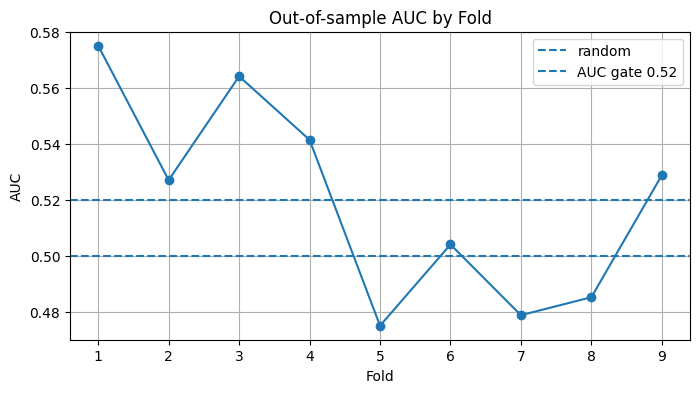

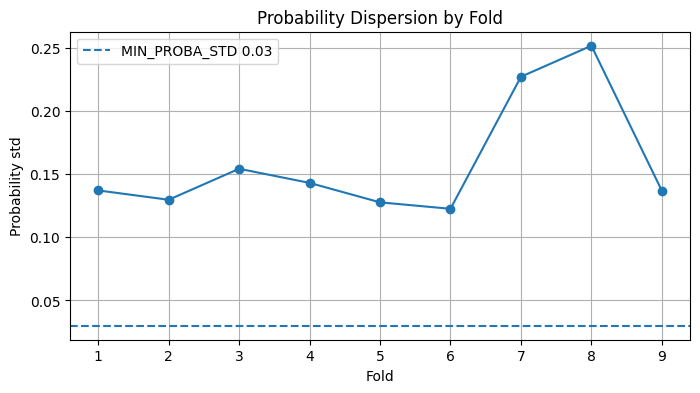

In [13]:
# =========================
# FOLD DIAGNOSTICS
# =========================

display(fold_diagnostics)

plt.figure(figsize=(8, 4))
plt.plot(fold_diagnostics["fold"], fold_diagnostics["auc"], marker="o")
plt.axhline(0.5, linestyle="--", label="random")
plt.axhline(AUC_GATE, linestyle="--", label=f"AUC gate {AUC_GATE}")
plt.xlabel("Fold")
plt.ylabel("AUC")
plt.title("Out-of-sample AUC by Fold")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(fold_diagnostics["fold"], fold_diagnostics["proba_std"], marker="o")
plt.axhline(MIN_PROBA_STD, linestyle="--", label=f"MIN_PROBA_STD {MIN_PROBA_STD}")
plt.xlabel("Fold")
plt.ylabel("Probability std")
plt.title("Probability Dispersion by Fold")
plt.legend()
plt.grid(True)
plt.show()


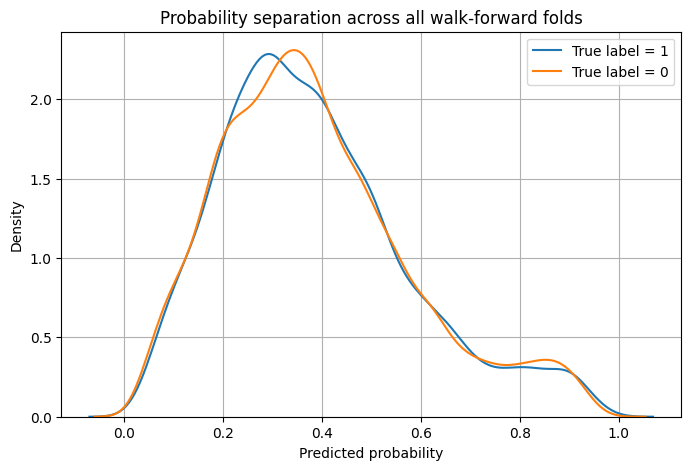

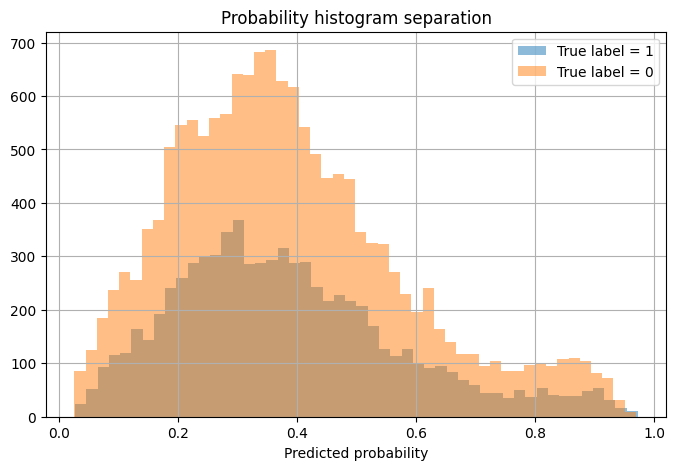

In [14]:
# =========================
# PROBABILITY SEPARATION ACROSS ALL OOS FOLDS
# =========================

proba_all = oos_predictions["proba"].values
y_all = oos_predictions["y_true"].values

plt.figure(figsize=(8, 5))
sns.kdeplot(proba_all[y_all == 1], label="True label = 1")
sns.kdeplot(proba_all[y_all == 0], label="True label = 0")
plt.legend()
plt.title("Probability separation across all walk-forward folds")
plt.xlabel("Predicted probability")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(proba_all[y_all == 1], bins=50, alpha=0.5, label="True label = 1")
plt.hist(proba_all[y_all == 0], bins=50, alpha=0.5, label="True label = 0")
plt.legend()
plt.title("Probability histogram separation")
plt.xlabel("Predicted probability")
plt.grid(True)
plt.show()


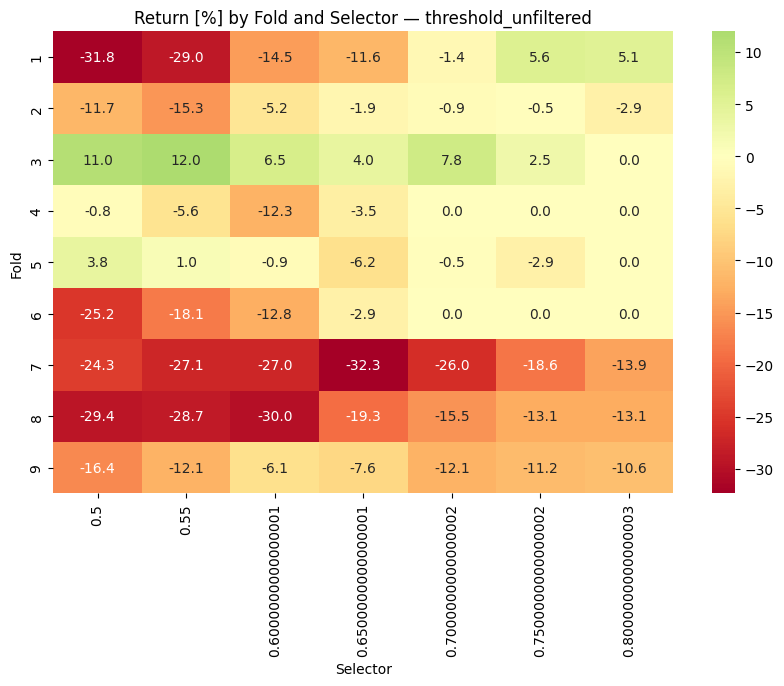

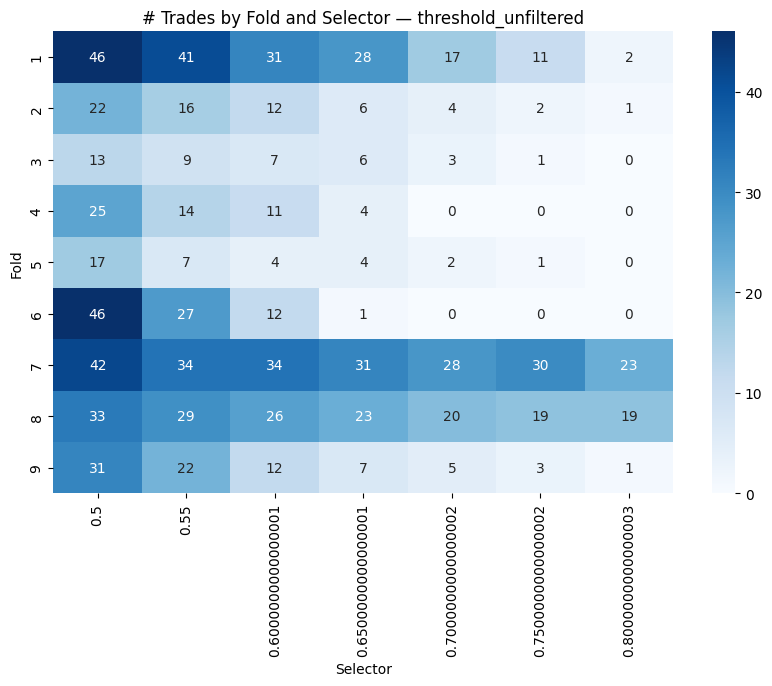

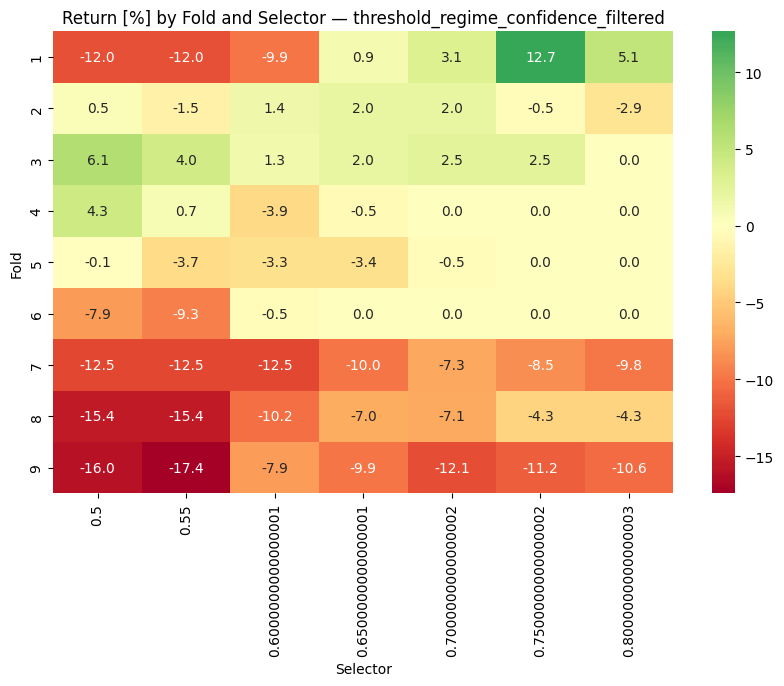

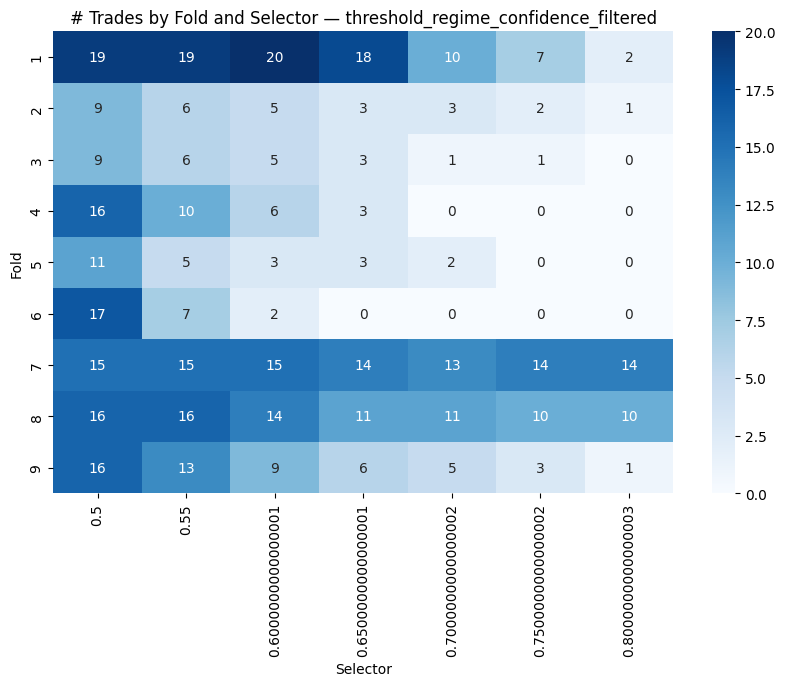

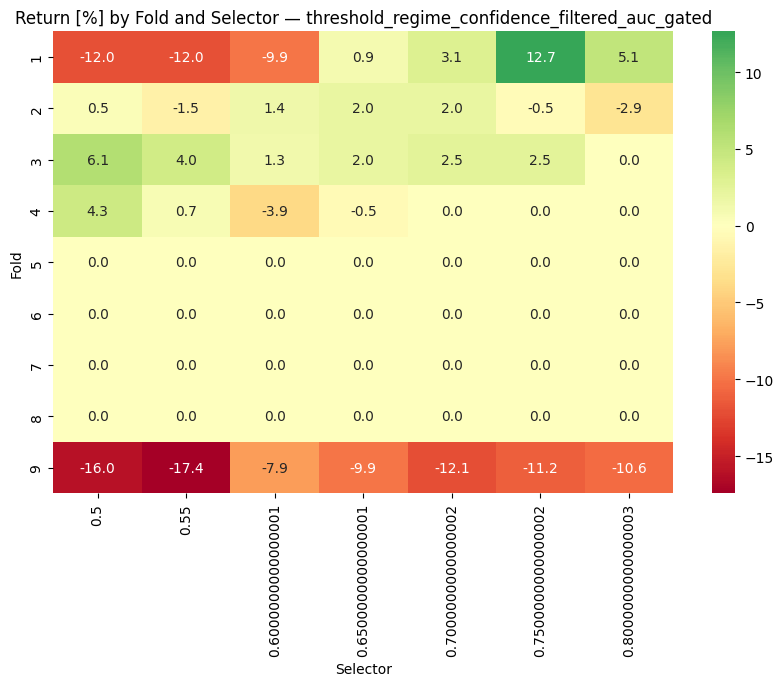

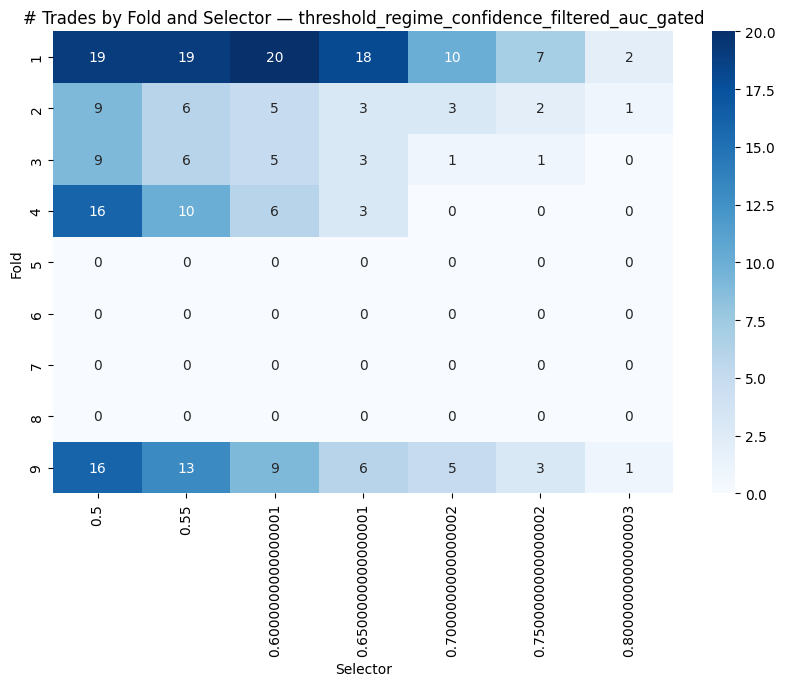

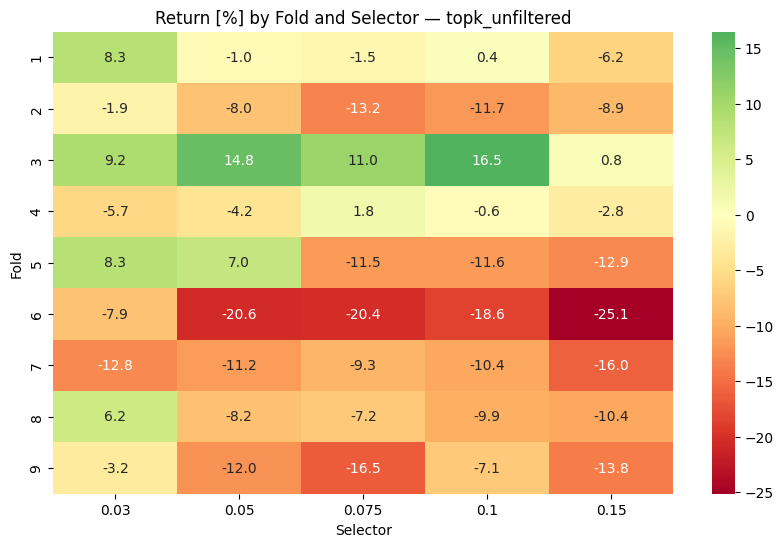

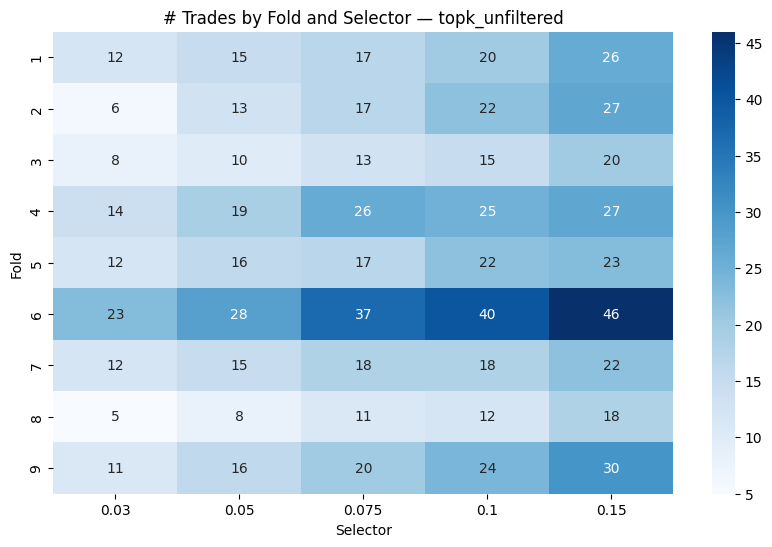

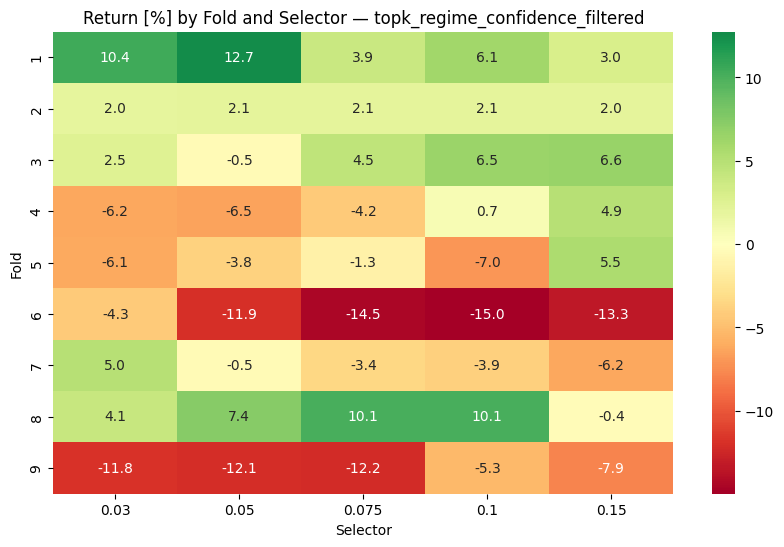

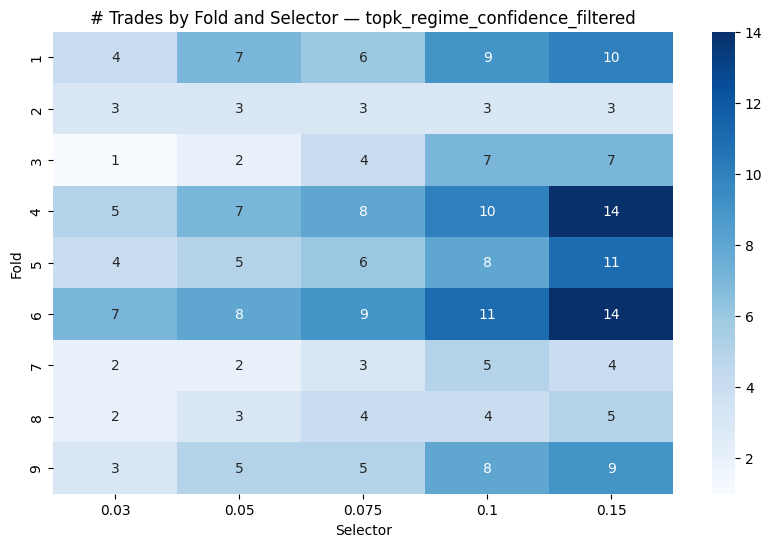

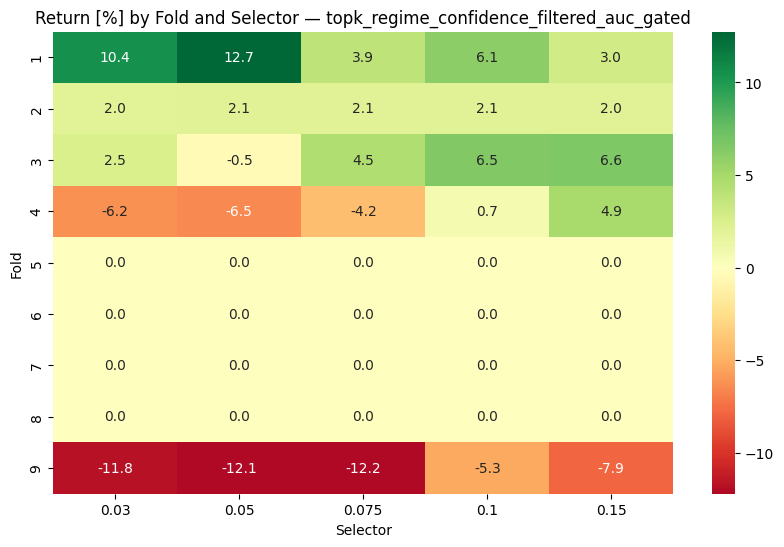

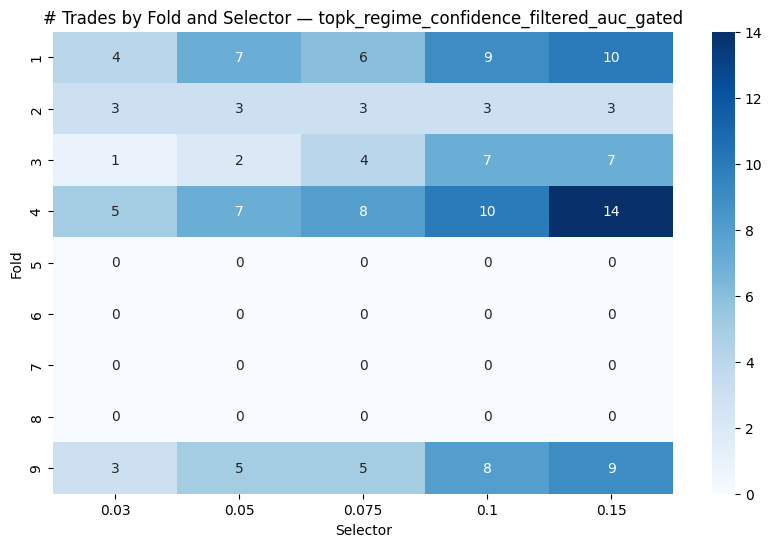

In [15]:
# =========================
# HEATMAPS: SELECTED MODES
# =========================

modes_to_plot = [
    "threshold_unfiltered",
    "threshold_regime_confidence_filtered",
    "threshold_regime_confidence_filtered_auc_gated",
    "topk_unfiltered",
    "topk_regime_confidence_filtered",
    "topk_regime_confidence_filtered_auc_gated",
]

for mode_name in modes_to_plot:
    tmp = wf_results[wf_results["mode"] == mode_name]

    if tmp.empty:
        continue

    pivot_ret = tmp.pivot(index="fold", columns="selector", values="return_pct")

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_ret, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
    plt.title(f"Return [%] by Fold and Selector — {mode_name}")
    plt.xlabel("Selector")
    plt.ylabel("Fold")
    plt.show()

    pivot_trades = tmp.pivot(index="fold", columns="selector", values="trades")

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_trades, annot=True, fmt=".0f", cmap="Blues")
    plt.title(f"# Trades by Fold and Selector — {mode_name}")
    plt.xlabel("Selector")
    plt.ylabel("Fold")
    plt.show()


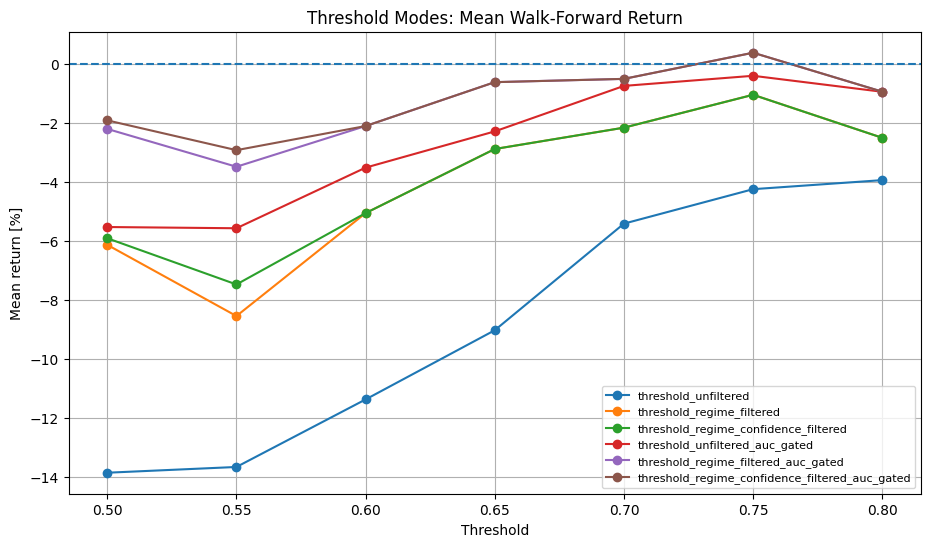

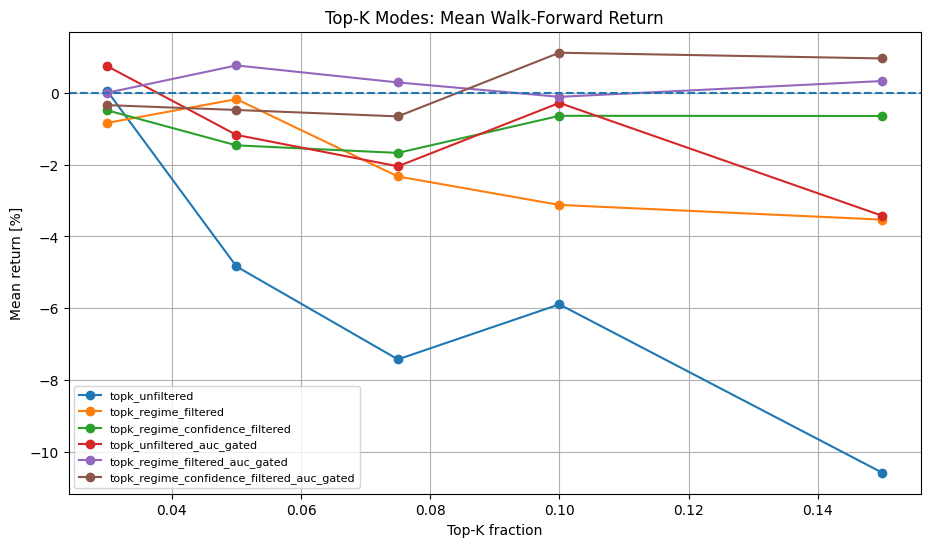

In [16]:
# =========================
# MODE COMPARISON PLOTS
# =========================

threshold_modes = [
    "threshold_unfiltered",
    "threshold_regime_filtered",
    "threshold_regime_confidence_filtered",
    "threshold_unfiltered_auc_gated",
    "threshold_regime_filtered_auc_gated",
    "threshold_regime_confidence_filtered_auc_gated",
]

topk_modes = [
    "topk_unfiltered",
    "topk_regime_filtered",
    "topk_regime_confidence_filtered",
    "topk_unfiltered_auc_gated",
    "topk_regime_filtered_auc_gated",
    "topk_regime_confidence_filtered_auc_gated",
]

plt.figure(figsize=(11, 6))
for mode_name in threshold_modes:
    tmp = summary[summary["mode"] == mode_name]
    if not tmp.empty:
        plt.plot(tmp["selector"], tmp["mean_return"], marker="o", label=mode_name)

plt.axhline(0, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("Mean return [%]")
plt.title("Threshold Modes: Mean Walk-Forward Return")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()


plt.figure(figsize=(11, 6))
for mode_name in topk_modes:
    tmp = summary[summary["mode"] == mode_name]
    if not tmp.empty:
        plt.plot(tmp["selector"], tmp["mean_return"], marker="o", label=mode_name)

plt.axhline(0, linestyle="--")
plt.xlabel("Top-K fraction")
plt.ylabel("Mean return [%]")
plt.title("Top-K Modes: Mean Walk-Forward Return")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()


Best robust configuration:


,mode,selector_type,selector,mean_return,median_return,min_return,std_return,positive_folds,mean_trades,total_trades,mean_precision,mean_recall,mean_auc,auc_pass_rate,mean_drawdown,worst_drawdown,mean_sharpe,robust_score
50,topk_regime_confidence_filtered_auc_gated,top_k_fraction,0.1,1.117622,0.0,-5.273725,3.540843,0.444444,4.111111,37.0,0.266444,0.020614,0.52005,0.555556,-3.533475,-11.565809,NaN,-0.197131


,fold,mode,selector,return_pct,trades,precision,recall,auc,auc_gate_passed,max_drawdown,sharpe
65,1,topk_regime_confidence_filtered_auc_gated,0.1,6.069698,9.0,0.594595,0.054455,0.575202,True,-5.209492,NaN
137,2,topk_regime_confidence_filtered_auc_gated,0.1,2.094829,3.0,0.360000,0.021277,0.527152,True,-3.116347,NaN
209,3,topk_regime_confidence_filtered_auc_gated,0.1,6.483200,7.0,0.615385,0.046404,0.564274,True,-4.204128,NaN
281,4,topk_regime_confidence_filtered_auc_gated,0.1,0.684597,10.0,0.409836,0.028539,0.541543,True,-7.705503,NaN
353,5,topk_regime_confidence_filtered_auc_gated,0.1,0.000000,0.0,0.000000,0.000000,0.475090,False,-0.000000,NaN
425,6,topk_regime_confidence_filtered_auc_gated,0.1,0.000000,0.0,0.000000,0.000000,0.504133,False,-0.000000,NaN
497,7,topk_regime_confidence_filtered_auc_gated,0.1,0.000000,0.0,0.000000,0.000000,0.478854,False,-0.000000,NaN
569,8,topk_regime_confidence_filtered_auc_gated,0.1,0.000000,0.0,0.000000,0.000000,0.485284,False,-0.000000,NaN
641,9,topk_regime_confidence_filtered_auc_gated,0.1,-5.273725,8.0,0.418182,0.034848,0.528915,True,-11.565809,NaN


Return stats:


count    9.000000
mean     1.117622
std      3.540843
min     -5.273725
25%      0.000000
50%      0.000000
75%      2.094829
max      6.483200
Name: return_pct, dtype: float64

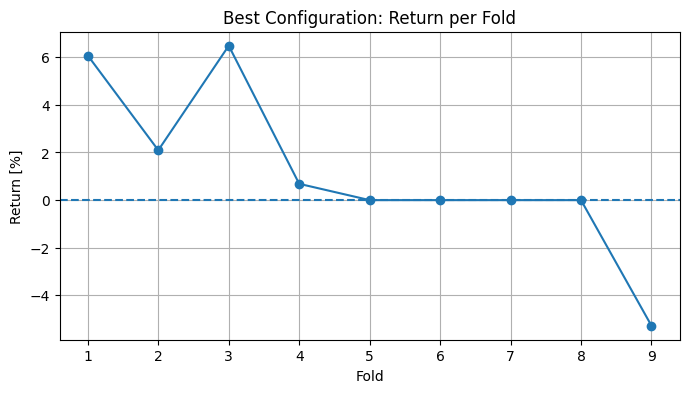

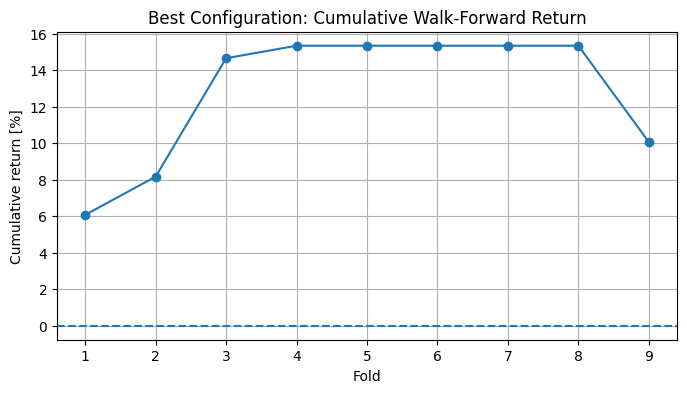

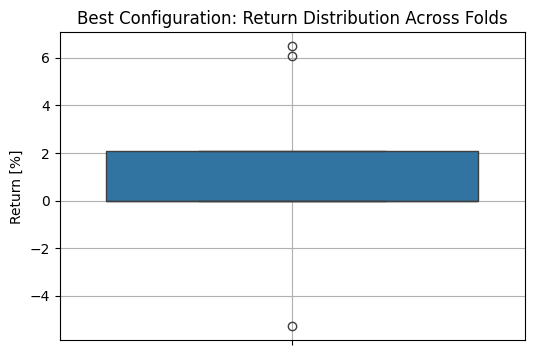

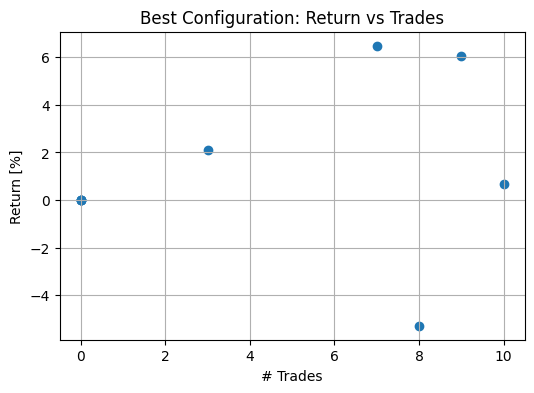

In [17]:
# =========================
# BEST CONFIGURATION DASHBOARD
# =========================

best = summary.sort_values("robust_score", ascending=False).iloc[0]

print("Best robust configuration:")
display(best.to_frame().T)

best_mode = best["mode"]
best_selector = best["selector"]

best_rows = wf_results[
    (wf_results["mode"] == best_mode)
    & (wf_results["selector"] == best_selector)
].copy().sort_values("fold")

display(best_rows[[
    "fold",
    "mode",
    "selector",
    "return_pct",
    "trades",
    "precision",
    "recall",
    "auc",
    "auc_gate_passed",
    "max_drawdown",
    "sharpe",
]])

print("Return stats:")
display(best_rows["return_pct"].describe())

plt.figure(figsize=(8, 4))
plt.plot(best_rows["fold"], best_rows["return_pct"], marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Fold")
plt.ylabel("Return [%]")
plt.title("Best Configuration: Return per Fold")
plt.grid(True)
plt.show()

best_rows["cum_return"] = best_rows["return_pct"].cumsum()

plt.figure(figsize=(8, 4))
plt.plot(best_rows["fold"], best_rows["cum_return"], marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Fold")
plt.ylabel("Cumulative return [%]")
plt.title("Best Configuration: Cumulative Walk-Forward Return")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(y=best_rows["return_pct"])
plt.title("Best Configuration: Return Distribution Across Folds")
plt.ylabel("Return [%]")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(best_rows["trades"], best_rows["return_pct"])
plt.xlabel("# Trades")
plt.ylabel("Return [%]")
plt.title("Best Configuration: Return vs Trades")
plt.grid(True)
plt.show()


In [18]:
# =========================
# PRECISION VS BASE RATE CHECK
# =========================

base_rate = df_model[target_col].mean()
best_precision = best_rows["precision"].mean()

print(f"Base rate: {base_rate:.4f}")
print(f"Best configuration mean precision: {best_precision:.4f}")
print(f"Precision lift: {best_precision - base_rate:.4f}")


Base rate: 0.3339
Best configuration mean precision: 0.2664
Precision lift: -0.0675


In [19]:
# =========================
# OPTIONAL: EXPORT RESULTS
# =========================

wf_results.to_csv("wf_full_system_results.csv", index=False)
summary.to_csv("wf_full_system_summary.csv", index=False)
fold_diagnostics.to_csv("wf_fold_diagnostics.csv", index=False)

print("Saved:")
print("wf_full_system_results.csv")
print("wf_full_system_summary.csv")
print("wf_fold_diagnostics.csv")


Saved:
wf_full_system_results.csv
wf_full_system_summary.csv
wf_fold_diagnostics.csv


## How to interpret

A configuration is interesting only if:

- `mean_return > 0`
- `median_return > 0`
- `min_return` is not catastrophic
- `positive_folds` is high
- `total_trades` is non-trivial
- nearby selector values also work
- precision is above base rate

Important caveat:

The AUC gate here uses test-fold AUC as a diagnostic. For a live system, replace this with a rolling validation-quality estimate computed only from past data.


In [20]:
bad_folds = [6, 7, 8]

bad_data = oos_predictions[oos_predictions["fold"].isin(bad_folds)].copy()
good_data = oos_predictions[~oos_predictions["fold"].isin(bad_folds)].copy()

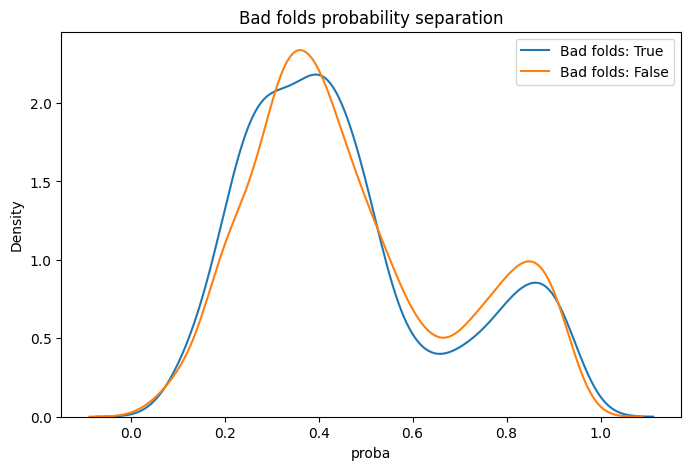

In [21]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(bad_data["proba"][bad_data["y_true"]==1], label="Bad folds: True")
sns.kdeplot(bad_data["proba"][bad_data["y_true"]==0], label="Bad folds: False")
plt.title("Bad folds probability separation")
plt.legend()
plt.show()

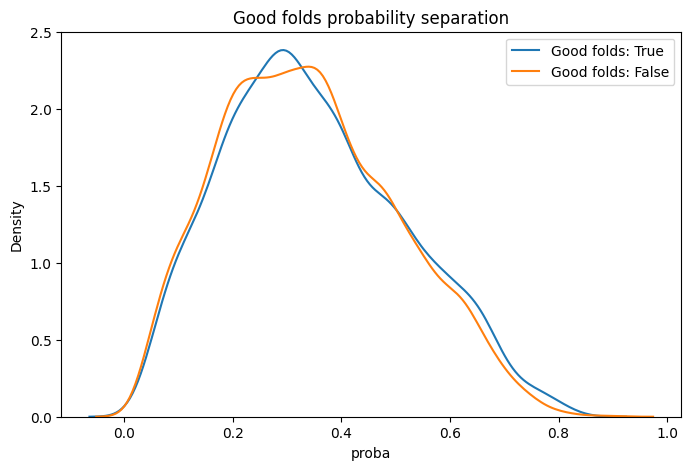

In [22]:
plt.figure(figsize=(8,5))
sns.kdeplot(good_data["proba"][good_data["y_true"]==1], label="Good folds: True")
sns.kdeplot(good_data["proba"][good_data["y_true"]==0], label="Good folds: False")
plt.title("Good folds probability separation")
plt.legend()
plt.show()

# PSR / DSR Diagnostics

This section evaluates the tested configurations using:

- **Probabilistic Sharpe Ratio (PSR)**: probability that true Sharpe is above a benchmark, usually 0.
- **Deflated Sharpe Ratio (DSR)**: PSR adjusted for multiple testing / data mining.

Here we use **fold-level returns** from walk-forward validation. This is useful for model-selection diagnostics. For final production-quality analysis, recompute using trade-level or daily/equity-curve returns.


In [23]:
from scipy.stats import skew, kurtosis, norm


In [24]:
# =========================
# PSR / DSR helper functions
# =========================

def sharpe_ratio_from_returns(returns, periods_per_year=None):
    """
    Compute Sharpe ratio from a return sample.

    returns should be decimal returns, e.g. 0.01 for +1%.
    If periods_per_year is None, returns non-annualized Sharpe.
    """
    r = np.asarray(returns, dtype=float)
    r = r[np.isfinite(r)]

    if len(r) < 2:
        return np.nan

    mu = np.mean(r)
    sigma = np.std(r, ddof=1)

    if sigma == 0:
        return np.nan

    sr = mu / sigma

    if periods_per_year is not None:
        sr *= np.sqrt(periods_per_year)

    return sr


def probabilistic_sharpe_ratio(returns, sr_benchmark=0.0):
    """
    Probabilistic Sharpe Ratio.

    Bailey / Lopez de Prado approximation:

    PSR = Phi( (SR_hat - SR*) * sqrt(n - 1)
               / sqrt(1 - skew*SR_hat + ((kurtosis - 1)/4)*SR_hat^2) )

    Here kurtosis is non-excess kurtosis: normal = 3.
    """
    r = np.asarray(returns, dtype=float)
    r = r[np.isfinite(r)]

    n = len(r)

    if n < 3:
        return np.nan

    sr_hat = sharpe_ratio_from_returns(r)

    if not np.isfinite(sr_hat):
        return np.nan

    gamma3 = skew(r, bias=False)
    gamma4 = kurtosis(r, fisher=False, bias=False)

    denom_inside = 1 - gamma3 * sr_hat + ((gamma4 - 1) / 4.0) * sr_hat**2

    if denom_inside <= 0:
        return np.nan

    z = (sr_hat - sr_benchmark) * np.sqrt(n - 1) / np.sqrt(denom_inside)

    return norm.cdf(z)


def expected_max_sharpe(n_trials):
    """
    Approximate expected maximum Sharpe from N independent trials.
    """
    if n_trials <= 1:
        return 0.0

    euler_gamma = 0.5772156649015329

    term1 = (1 - euler_gamma) * norm.ppf(1 - 1 / n_trials)
    term2 = euler_gamma * norm.ppf(1 - 1 / (n_trials * np.e))

    return term1 + term2


def deflated_sharpe_ratio(returns, n_trials):
    """
    Practical DSR approximation:
    PSR measured against expected maximum Sharpe under n_trials.
    """
    sr0 = expected_max_sharpe(n_trials)
    return probabilistic_sharpe_ratio(returns, sr_benchmark=sr0)


def summarize_config_psr_dsr(group, n_trials):
    """
    Summarize one configuration using fold-level walk-forward returns.
    """
    rets = group["return_pct"].values / 100.0

    sr = sharpe_ratio_from_returns(rets)
    psr0 = probabilistic_sharpe_ratio(rets, sr_benchmark=0.0)
    dsr = deflated_sharpe_ratio(rets, n_trials=n_trials)

    out = {
        "n_folds": len(rets),
        "mean_return_pct": group["return_pct"].mean(),
        "median_return_pct": group["return_pct"].median(),
        "min_return_pct": group["return_pct"].min(),
        "std_return_pct": group["return_pct"].std(),
        "positive_folds": (group["return_pct"] > 0).mean(),
        "total_trades": group["trades"].sum(),
        "mean_trades": group["trades"].mean(),
        "mean_precision": group["precision"].mean(),
        "mean_recall": group["recall"].mean(),
        "mean_auc": group["auc"].mean(),
        "mean_drawdown": group["max_drawdown"].mean(),
        "worst_drawdown": group["max_drawdown"].min(),
        "mean_sharpe_bt": group["sharpe"].mean(),
        "sharpe_fold": sr,
        "psr_gt_0": psr0,
        "dsr": dsr,
    }

    if "auc_gate_passed" in group.columns:
        out["auc_pass_rate"] = group["auc_gate_passed"].mean()

    return pd.Series(out)


In [25]:
# =========================
# Compute PSR / DSR for every tested configuration
# =========================

config_cols = ["mode", "selector_type", "selector"]

n_trials = (
    wf_results[config_cols]
    .drop_duplicates()
    .shape[0]
)

print("Number of tested configurations / trials:", n_trials)

psr_dsr_summary = (
    wf_results
    .groupby(config_cols)
    .apply(lambda g: summarize_config_psr_dsr(g, n_trials=n_trials))
    .reset_index()
)

# Composite score emphasizing robustness and statistical credibility.
psr_dsr_summary["robust_score_psr_dsr"] = (
    psr_dsr_summary["mean_return_pct"]
    + 0.50 * psr_dsr_summary["median_return_pct"]
    + 0.25 * psr_dsr_summary["min_return_pct"]
    - 0.25 * psr_dsr_summary["std_return_pct"].fillna(0)
    + 2.00 * psr_dsr_summary["positive_folds"]
    + 2.00 * psr_dsr_summary["psr_gt_0"].fillna(0)
    + 3.00 * psr_dsr_summary["dsr"].fillna(0)
)

display(
    psr_dsr_summary
    .sort_values("robust_score_psr_dsr", ascending=False)
    .head(30)
)


Number of tested configurations / trials: 72


/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_4636/3749255879.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: summarize_config_psr_dsr(g, n_trials=n_trials))


,mode,selector_type,selector,n_folds,mean_return_pct,median_return_pct,min_return_pct,std_return_pct,positive_folds,total_trades,...,mean_recall,mean_auc,mean_drawdown,worst_drawdown,mean_sharpe_bt,sharpe_fold,psr_gt_0,dsr,auc_pass_rate,robust_score_psr_dsr
50,topk_regime_confidence_filtered_auc_gated,top_k_fraction,0.100,9.0,1.117622,0.000000,-5.273725,3.540843,0.444444,37.0,...,0.020614,0.52005,-3.533475,-11.565809,NaN,0.315637,0.807484,3.927585e-09,0.555556,1.417838
51,topk_regime_confidence_filtered_auc_gated,top_k_fraction,0.150,9.0,0.958454,0.000000,-7.907219,4.108552,0.444444,43.0,...,0.028108,0.52005,-3.542566,-11.565976,NaN,0.233283,0.718362,3.333358e-08,0.555556,0.280123
58,topk_regime_filtered_auc_gated,top_k_fraction,0.050,9.0,0.763504,0.000000,-7.907219,3.860157,0.444444,40.0,...,0.024328,0.52005,-3.782684,-11.565976,NaN,0.197791,0.686943,2.434475e-08,0.555556,0.084436
67,topk_unfiltered_auc_gated,top_k_fraction,0.030,9.0,0.742195,0.000000,-5.694606,4.929510,0.222222,51.0,...,0.020869,0.52005,-5.084654,-15.367546,NaN,0.150562,0.675646,3.828256e-12,0.555556,-0.118098
53,topk_regime_filtered,top_k_fraction,0.050,9.0,-0.175156,3.010548,-11.116111,6.426685,0.666667,74.0,...,0.037609,0.52005,-7.776390,-13.526986,NaN,-0.027254,0.468914,1.443850e-12,0.555556,-0.784418
42,topk_regime_confidence_filtered,top_k_fraction,0.030,9.0,-0.487772,2.009561,-11.804222,7.013384,0.555556,31.0,...,0.009291,0.52005,-5.283859,-11.954609,NaN,-0.069549,0.421756,9.228676e-13,0.555556,-2.232769
12,threshold_regime_confidence_filtered_auc_gated,threshold,0.750,9.0,0.384879,0.000000,-11.228676,6.034442,0.222222,13.0,...,0.006252,0.52005,-2.665867,-11.501882,NaN,0.063780,0.571853,1.282269e-11,0.555556,-2.342749
26,threshold_regime_filtered_auc_gated,threshold,0.750,9.0,0.384879,0.000000,-11.228676,6.034442,0.222222,13.0,...,0.006252,0.52005,-2.665867,-11.501882,NaN,0.063780,0.571853,1.282269e-11,0.555556,-2.342749
46,topk_regime_confidence_filtered,top_k_fraction,0.150,9.0,-0.645703,2.037866,-13.277681,6.941462,0.555556,77.0,...,0.044248,0.52005,-7.782237,-15.629925,NaN,-0.093021,0.392282,8.910373e-14,0.555556,-2.785881
24,threshold_regime_filtered_auc_gated,threshold,0.650,9.0,-0.613270,0.000000,-9.927272,3.612486,0.333333,33.0,...,0.028403,0.52005,-3.733588,-11.566471,NaN,-0.169764,0.271613,1.139722e-20,0.555556,-2.788317


In [26]:
# =========================
# Top configurations by DSR vs by mean return
# =========================

print("Top by DSR:")
display(
    psr_dsr_summary
    .sort_values("dsr", ascending=False)
    .head(20)
)

print("Top by mean return:")
display(
    psr_dsr_summary
    .sort_values("mean_return_pct", ascending=False)
    .head(20)
)


Top by DSR:


,mode,selector_type,selector,n_folds,mean_return_pct,median_return_pct,min_return_pct,std_return_pct,positive_folds,total_trades,...,mean_recall,mean_auc,mean_drawdown,worst_drawdown,mean_sharpe_bt,sharpe_fold,psr_gt_0,dsr,auc_pass_rate,robust_score_psr_dsr
51,topk_regime_confidence_filtered_auc_gated,top_k_fraction,0.150,9.0,0.958454,0.000000,-7.907219,4.108552,0.444444,43.0,...,0.028108,0.52005,-3.542566,-11.565976,NaN,0.233283,0.718362,3.333358e-08,0.555556,0.280123
58,topk_regime_filtered_auc_gated,top_k_fraction,0.050,9.0,0.763504,0.000000,-7.907219,3.860157,0.444444,40.0,...,0.024328,0.52005,-3.782684,-11.565976,NaN,0.197791,0.686943,2.434475e-08,0.555556,0.084436
65,topk_unfiltered,top_k_fraction,0.100,9.0,-5.893808,-9.928551,-18.582541,10.210034,0.222222,198.0,...,0.110860,0.52005,-16.233897,-28.001438,NaN,-0.577256,0.132887,4.101096e-09,0.555556,-17.346008
50,topk_regime_confidence_filtered_auc_gated,top_k_fraction,0.100,9.0,1.117622,0.000000,-5.273725,3.540843,0.444444,37.0,...,0.020614,0.52005,-3.533475,-11.565809,NaN,0.315637,0.807484,3.927585e-09,0.555556,1.417838
59,topk_regime_filtered_auc_gated,top_k_fraction,0.075,9.0,0.289715,0.000000,-17.999589,7.529106,0.444444,51.0,...,0.033210,0.52005,-4.346672,-18.362688,NaN,0.038479,0.541728,5.039166e-11,0.555556,-4.120114
61,topk_regime_filtered_auc_gated,top_k_fraction,0.150,9.0,0.328773,0.000000,-17.605612,8.136035,0.333333,75.0,...,0.061612,0.52005,-6.086661,-19.150561,NaN,0.040409,0.544573,2.464370e-11,0.555556,-4.350826
64,topk_unfiltered,top_k_fraction,0.075,9.0,-7.426009,-9.316800,-20.356447,9.751641,0.222222,176.0,...,0.084126,0.52005,-16.019019,-30.672522,NaN,-0.761514,0.056170,1.815264e-11,0.555556,-19.054646
26,threshold_regime_filtered_auc_gated,threshold,0.750,9.0,0.384879,0.000000,-11.228676,6.034442,0.222222,13.0,...,0.006252,0.52005,-2.665867,-11.501882,NaN,0.063780,0.571853,1.282269e-11,0.555556,-2.342749
12,threshold_regime_confidence_filtered_auc_gated,threshold,0.750,9.0,0.384879,0.000000,-11.228676,6.034442,0.222222,13.0,...,0.006252,0.52005,-2.665867,-11.501882,NaN,0.063780,0.571853,1.282269e-11,0.555556,-2.342749
68,topk_unfiltered_auc_gated,top_k_fraction,0.050,9.0,-1.172999,0.000000,-12.043202,7.365986,0.111111,73.0,...,0.032252,0.52005,-6.200683,-17.828735,NaN,-0.159245,0.339520,1.170543e-11,0.555556,-5.124034


Top by mean return:


,mode,selector_type,selector,n_folds,mean_return_pct,median_return_pct,min_return_pct,std_return_pct,positive_folds,total_trades,...,mean_recall,mean_auc,mean_drawdown,worst_drawdown,mean_sharpe_bt,sharpe_fold,psr_gt_0,dsr,auc_pass_rate,robust_score_psr_dsr
50,topk_regime_confidence_filtered_auc_gated,top_k_fraction,0.100,9.0,1.117622,0.000000,-5.273725,3.540843,0.444444,37.0,...,0.020614,0.52005,-3.533475,-11.565809,NaN,0.315637,0.807484,3.927585e-09,0.555556,1.417838
51,topk_regime_confidence_filtered_auc_gated,top_k_fraction,0.150,9.0,0.958454,0.000000,-7.907219,4.108552,0.444444,43.0,...,0.028108,0.52005,-3.542566,-11.565976,NaN,0.233283,0.718362,3.333358e-08,0.555556,0.280123
58,topk_regime_filtered_auc_gated,top_k_fraction,0.050,9.0,0.763504,0.000000,-7.907219,3.860157,0.444444,40.0,...,0.024328,0.52005,-3.782684,-11.565976,NaN,0.197791,0.686943,2.434475e-08,0.555556,0.084436
67,topk_unfiltered_auc_gated,top_k_fraction,0.030,9.0,0.742195,0.000000,-5.694606,4.929510,0.222222,51.0,...,0.020869,0.52005,-5.084654,-15.367546,NaN,0.150562,0.675646,3.828256e-12,0.555556,-0.118098
12,threshold_regime_confidence_filtered_auc_gated,threshold,0.750,9.0,0.384879,0.000000,-11.228676,6.034442,0.222222,13.0,...,0.006252,0.52005,-2.665867,-11.501882,NaN,0.063780,0.571853,1.282269e-11,0.555556,-2.342749
26,threshold_regime_filtered_auc_gated,threshold,0.750,9.0,0.384879,0.000000,-11.228676,6.034442,0.222222,13.0,...,0.006252,0.52005,-2.665867,-11.501882,NaN,0.063780,0.571853,1.282269e-11,0.555556,-2.342749
61,topk_regime_filtered_auc_gated,top_k_fraction,0.150,9.0,0.328773,0.000000,-17.605612,8.136035,0.333333,75.0,...,0.061612,0.52005,-6.086661,-19.150561,NaN,0.040409,0.544573,2.464370e-11,0.555556,-4.350826
59,topk_regime_filtered_auc_gated,top_k_fraction,0.075,9.0,0.289715,0.000000,-17.999589,7.529106,0.444444,51.0,...,0.033210,0.52005,-4.346672,-18.362688,NaN,0.038479,0.541728,5.039166e-11,0.555556,-4.120114
62,topk_unfiltered,top_k_fraction,0.030,9.0,0.048154,-1.898548,-12.821930,8.170499,0.444444,103.0,...,0.036631,0.52005,-11.100676,-21.035466,NaN,0.005894,0.506646,5.114861e-12,0.555556,-4.247047
57,topk_regime_filtered_auc_gated,top_k_fraction,0.030,9.0,0.002434,0.000000,-12.204780,5.997564,0.333333,26.0,...,0.015697,0.52005,-3.829762,-12.284175,NaN,0.000406,0.500458,4.477987e-12,0.555556,-2.880570


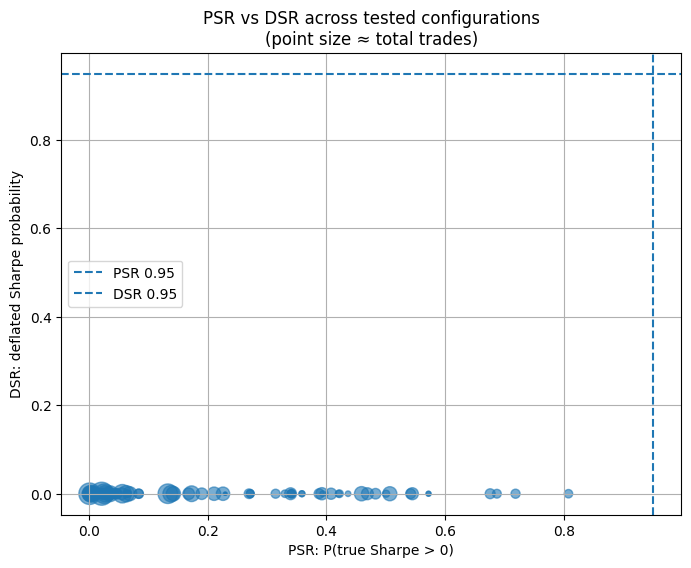

In [27]:
# =========================
# PSR vs DSR scatter
# =========================

plt.figure(figsize=(8, 6))

sizes = np.clip(psr_dsr_summary["total_trades"].fillna(0), 5, 300)

plt.scatter(
    psr_dsr_summary["psr_gt_0"],
    psr_dsr_summary["dsr"],
    s=sizes,
    alpha=0.6,
)

plt.axvline(0.95, linestyle="--", label="PSR 0.95")
plt.axhline(0.95, linestyle="--", label="DSR 0.95")
plt.xlabel("PSR: P(true Sharpe > 0)")
plt.ylabel("DSR: deflated Sharpe probability")
plt.title("PSR vs DSR across tested configurations\n(point size ≈ total trades)")
plt.legend()
plt.grid(True)
plt.show()


,mode,best_mean_return,best_median_return,best_psr,best_dsr,best_robust_score,configs
7,topk_regime_confidence_filtered_auc_gated,1.117622,0.000000,0.807484,3.333358e-08,1.417838,5
9,topk_regime_filtered_auc_gated,0.763504,0.000000,0.686943,2.434475e-08,0.084436,5
11,topk_unfiltered_auc_gated,0.742195,0.000000,0.675646,1.170543e-11,-0.118098,5
8,topk_regime_filtered,-0.175156,3.010548,0.468914,1.443850e-12,-0.784418,5
6,topk_regime_confidence_filtered,-0.487772,2.037866,0.421756,9.228676e-13,-2.232769,5
1,threshold_regime_confidence_filtered_auc_gated,0.384879,0.000000,0.571853,1.282269e-11,-2.342749,7
3,threshold_regime_filtered_auc_gated,0.384879,0.000000,0.571853,1.282269e-11,-2.342749,7
5,threshold_unfiltered_auc_gated,-0.397476,0.000000,0.393710,1.004581e-14,-3.099959,7
10,topk_unfiltered,0.048154,-1.898548,0.506646,4.101096e-09,-4.247047,5
0,threshold_regime_confidence_filtered,-1.041513,0.000000,0.340951,2.562494e-12,-4.431696,7


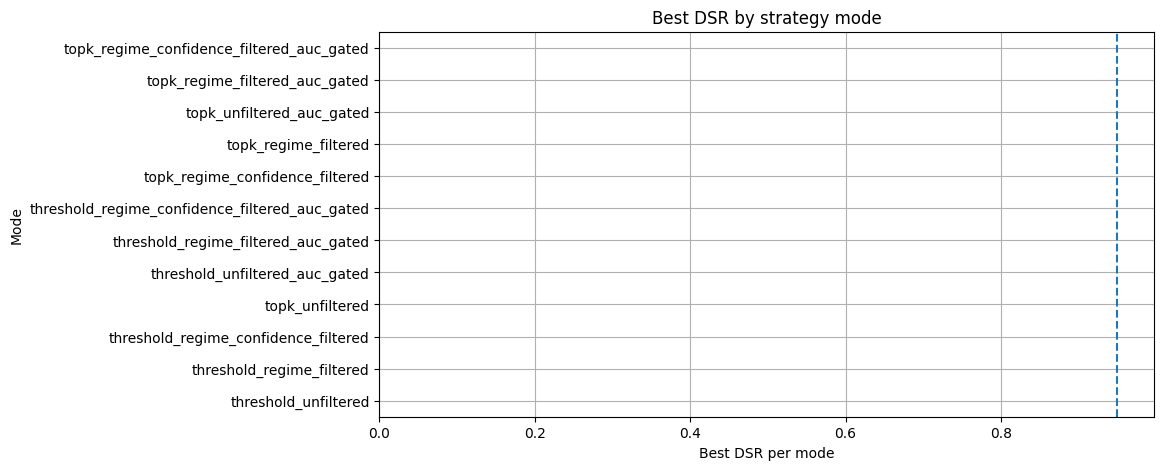

In [28]:
# =========================
# Mode-level statistical credibility
# =========================

mode_psr_dsr_summary = (
    psr_dsr_summary
    .groupby("mode")
    .agg(
        best_mean_return=("mean_return_pct", "max"),
        best_median_return=("median_return_pct", "max"),
        best_psr=("psr_gt_0", "max"),
        best_dsr=("dsr", "max"),
        best_robust_score=("robust_score_psr_dsr", "max"),
        configs=("mode", "count"),
    )
    .reset_index()
    .sort_values("best_robust_score", ascending=False)
)

display(mode_psr_dsr_summary)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=mode_psr_dsr_summary,
    x="best_dsr",
    y="mode",
)
plt.axvline(0.95, linestyle="--")
plt.xlabel("Best DSR per mode")
plt.ylabel("Mode")
plt.title("Best DSR by strategy mode")
plt.grid(True)
plt.show()


Best DSR configuration:


,mode,selector_type,selector,n_folds,mean_return_pct,median_return_pct,min_return_pct,std_return_pct,positive_folds,total_trades,...,mean_recall,mean_auc,mean_drawdown,worst_drawdown,mean_sharpe_bt,sharpe_fold,psr_gt_0,dsr,auc_pass_rate,robust_score_psr_dsr
51,topk_regime_confidence_filtered_auc_gated,top_k_fraction,0.15,9.0,0.958454,0.0,-7.907219,4.108552,0.444444,43.0,...,0.028108,0.52005,-3.542566,-11.565976,NaN,0.233283,0.718362,0.0,0.555556,0.280123


,fold,mode,selector,return_pct,trades,precision,recall,auc,max_drawdown,sharpe
71,1,topk_regime_confidence_filtered_auc_gated,0.15,2.962159,10.0,0.504505,0.069307,0.575202,-5.982386,NaN
143,2,topk_regime_confidence_filtered_auc_gated,0.15,2.037866,3.0,0.320000,0.028369,0.527152,-2.929476,NaN
215,3,topk_regime_confidence_filtered_auc_gated,0.15,6.588124,7.0,0.567010,0.063805,0.564274,-4.225613,NaN
287,4,topk_regime_confidence_filtered_auc_gated,0.15,4.945156,14.0,0.428571,0.044521,0.541543,-7.179641,NaN
359,5,topk_regime_confidence_filtered_auc_gated,0.15,0.000000,0.0,0.000000,0.000000,0.475090,-0.000000,NaN
431,6,topk_regime_confidence_filtered_auc_gated,0.15,0.000000,0.0,0.000000,0.000000,0.504133,-0.000000,NaN
503,7,topk_regime_confidence_filtered_auc_gated,0.15,0.000000,0.0,0.000000,0.000000,0.478854,-0.000000,NaN
575,8,topk_regime_confidence_filtered_auc_gated,0.15,0.000000,0.0,0.000000,0.000000,0.485284,-0.000000,NaN
647,9,topk_regime_confidence_filtered_auc_gated,0.15,-7.907219,9.0,0.373494,0.046970,0.528915,-11.565976,NaN


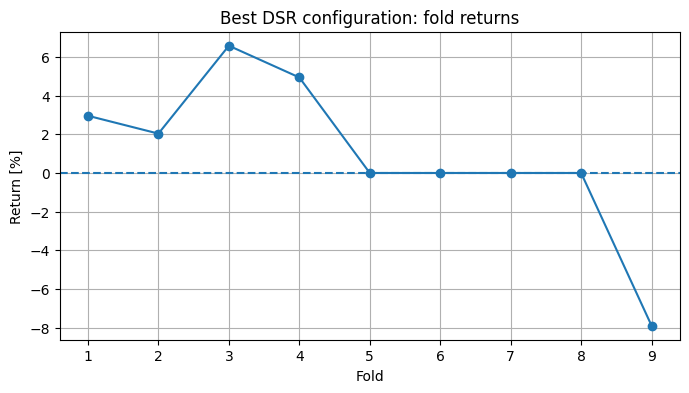

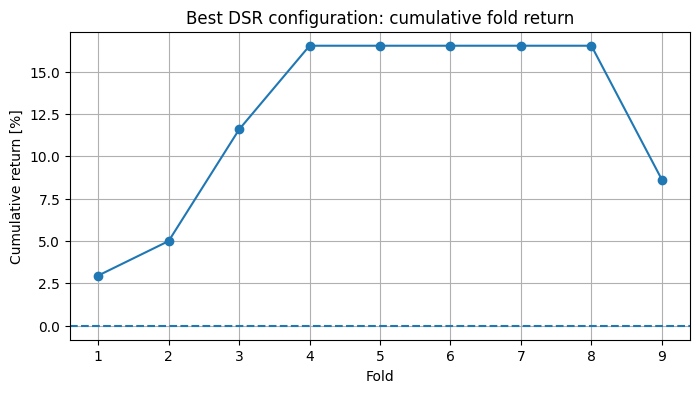

In [29]:
# =========================
# Best DSR configuration dashboard
# =========================

best_dsr_row = psr_dsr_summary.sort_values("dsr", ascending=False).iloc[0]

print("Best DSR configuration:")
display(best_dsr_row.to_frame().T)

best_dsr_mode = best_dsr_row["mode"]
best_dsr_selector_type = best_dsr_row["selector_type"]
best_dsr_selector = best_dsr_row["selector"]

best_dsr_rows = wf_results[
    (wf_results["mode"] == best_dsr_mode)
    & (wf_results["selector_type"] == best_dsr_selector_type)
    & (wf_results["selector"] == best_dsr_selector)
].copy().sort_values("fold")

display(best_dsr_rows[[
    "fold",
    "mode",
    "selector",
    "return_pct",
    "trades",
    "precision",
    "recall",
    "auc",
    "max_drawdown",
    "sharpe",
]])

plt.figure(figsize=(8, 4))
plt.plot(best_dsr_rows["fold"], best_dsr_rows["return_pct"], marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Fold")
plt.ylabel("Return [%]")
plt.title("Best DSR configuration: fold returns")
plt.grid(True)
plt.show()

best_dsr_rows["cum_return"] = best_dsr_rows["return_pct"].cumsum()

plt.figure(figsize=(8, 4))
plt.plot(best_dsr_rows["fold"], best_dsr_rows["cum_return"], marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Fold")
plt.ylabel("Cumulative return [%]")
plt.title("Best DSR configuration: cumulative fold return")
plt.grid(True)
plt.show()


In [30]:
# =========================
# Export full results including PSR / DSR
# =========================

wf_results.to_csv("wf_full_system_results.csv", index=False)
summary.to_csv("wf_full_system_summary.csv", index=False)
fold_diagnostics.to_csv("wf_fold_diagnostics.csv", index=False)
psr_dsr_summary.to_csv("wf_psr_dsr_summary.csv", index=False)
mode_psr_dsr_summary.to_csv("wf_psr_dsr_mode_summary.csv", index=False)

print("Saved:")
print("wf_full_system_results.csv")
print("wf_full_system_summary.csv")
print("wf_fold_diagnostics.csv")
print("wf_psr_dsr_summary.csv")
print("wf_psr_dsr_mode_summary.csv")


Saved:
wf_full_system_results.csv
wf_full_system_summary.csv
wf_fold_diagnostics.csv
wf_psr_dsr_summary.csv
wf_psr_dsr_mode_summary.csv


## How to read PSR / DSR

A configuration becomes more credible if:

- `PSR > 0.95`
- `DSR > 0.95`
- positive median fold return
- non-trivial trade count
- no catastrophic worst fold

If PSR is high but DSR is low, the result is probably inflated by trying many configurations.

Caveat: this implementation uses fold-level returns. For final validation, recompute PSR/DSR on trade-level returns or daily/equity-curve returns.
